# Frankenstein Summary ("orbit1234only_narrower_1M" run)

Consolidated, validated results for the `Frankenstein_He_electron2_orbit1234only_narrower_1M`
CQSFA_fwd run, distilled from `Frankenstein_orbit1234_narrower_1M.ipynb` (which contains the full
debugging history: root-cause analysis of the >2Up action-formula bug, the griddata-interpolation
noise/fringes bug, and their fixes).

Four sections:
1. CQSFA native ATI spectra (full prefactor & Coulomb-corrected-action-only/`qPref`), per orbit
   type + combined - bare (no-prefactor) intentionally excluded.
2. Initial conditions (`Binned_Initial_Condition_Grid`), combined and split by orbit type.
3. Frankenstein joint (p1,p2) distributions for orbits 1,2,3,4,1+2,3+4,1+2+3+4 and the standard
   SFA RESI reference - built via the validated **separable, no-interpolation** method (electron
   2's marginal read directly off CQSFA_fwd's own native `Amplitude_Grid`, never griddata-
   interpolated), consistent `p/sqrt(Up)` units throughout, with 2Up bounds marked.
4. Electron momentum distributions: electron 1 (pure SFA), electron 2 (pure SFA), electron 2
   (CQSFA, orbits 1+2+3+4 combined, full prefactor), and CQSFA stability-only (`qPref`).

In [3]:
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.interpolate import griddata

ATTOPYTHON_ROOT = "/workspaces/CQSFA/AttoPython"
if ATTOPYTHON_ROOT not in sys.path:
    sys.path.insert(0, ATTOPYTHON_ROOT)

import importlib
import Source.CQSFA
importlib.reload(Source.CQSFA)  # kernel may already have an older cached copy of this module
from Source.CQSFA import RESIParams, load_orbit, compute_electron1_times, compute_M, compute_M_native

CQSFA_dir = "/workspaces/CQSFA/CQSFA_fwd/runs/Frankenstein_He_electron2_orbit1234only_narrower_1M"
RUN_TAG = "orbit1234only_narrower_1M"
NINITCOND_TAG = "1e+06"  # NInitCond is stream-formatted as a double -> "1e+06", not "1000000"
AMP_GRID_TAG = "500X500X1"
Nz = Ny = 500

OrbitFinder_dir = "/workspaces/CQSFA/OrbitFinder/TestingSuite"
GRID_TAG = "141X141"  # OrbitFinder's own p_long x p_trans grid (unaffected by CQSFA aSoft/sigma)

omega = 0.057
Up = 0.6579
Up0 = Up / omega

Ip1, Ip2, Ip12 = 0.97, 2.0, 0.5  # I1g, I2g, I2e (Helium RESI channel)
BUMP = 1e-4
params = RESIParams(omega=omega, Up0=Up0, Ip1=Ip1, Ip2=Ip2, Ip12=Ip12, BUMP=BUMP)

pax, tax, T1S, T2S, T3S = load_orbit(f"{OrbitFinder_dir}/results/helium_resi_cross_quadrant.inp_Range_{GRID_TAG}_channel:0.shortorbit")
_, _, T1L, T2L, T3L = load_orbit(f"{OrbitFinder_dir}/results/helium_resi_cross_quadrant.inp_Range_{GRID_TAG}_channel:0.longorbit")
n = len(pax)
hsize = int(np.floor(n / 2.0 + 0.5))  # C++ std::round (round-half-away-from-zero)
tax_half = pax[:hsize]
print(f"grid {n}x{n}, hsize={hsize}, p_trans (half) in [{tax_half.min():.3f},{tax_half.max():.3f}]")

e1_times = compute_electron1_times(params, pax, tax_half, T1S, T2S, T1L, T2L)

p1trans_w = tax_half[None, None, :, None]
p2trans_w = tax_half[None, None, None, :]


grid 141x141, hsize=71, p_trans (half) in [-4.315,0.000]


## 1. CQSFA native ATI spectra: full prefactor & Coulomb-corrected-action-only (`qPref`)

Per orbit type (1-4) + combined (1+2+3+4) - straight from CQSFA_fwd's own native `Amplitude_Grid`
files, no interpolation or reconstruction involved. Bare (no-prefactor) `|M|^2` intentionally
excluded - it is not a valid standalone physical observable (see repo notes: it treats every
found saddle point with equal unit weight, violating the stationary-phase normalization).

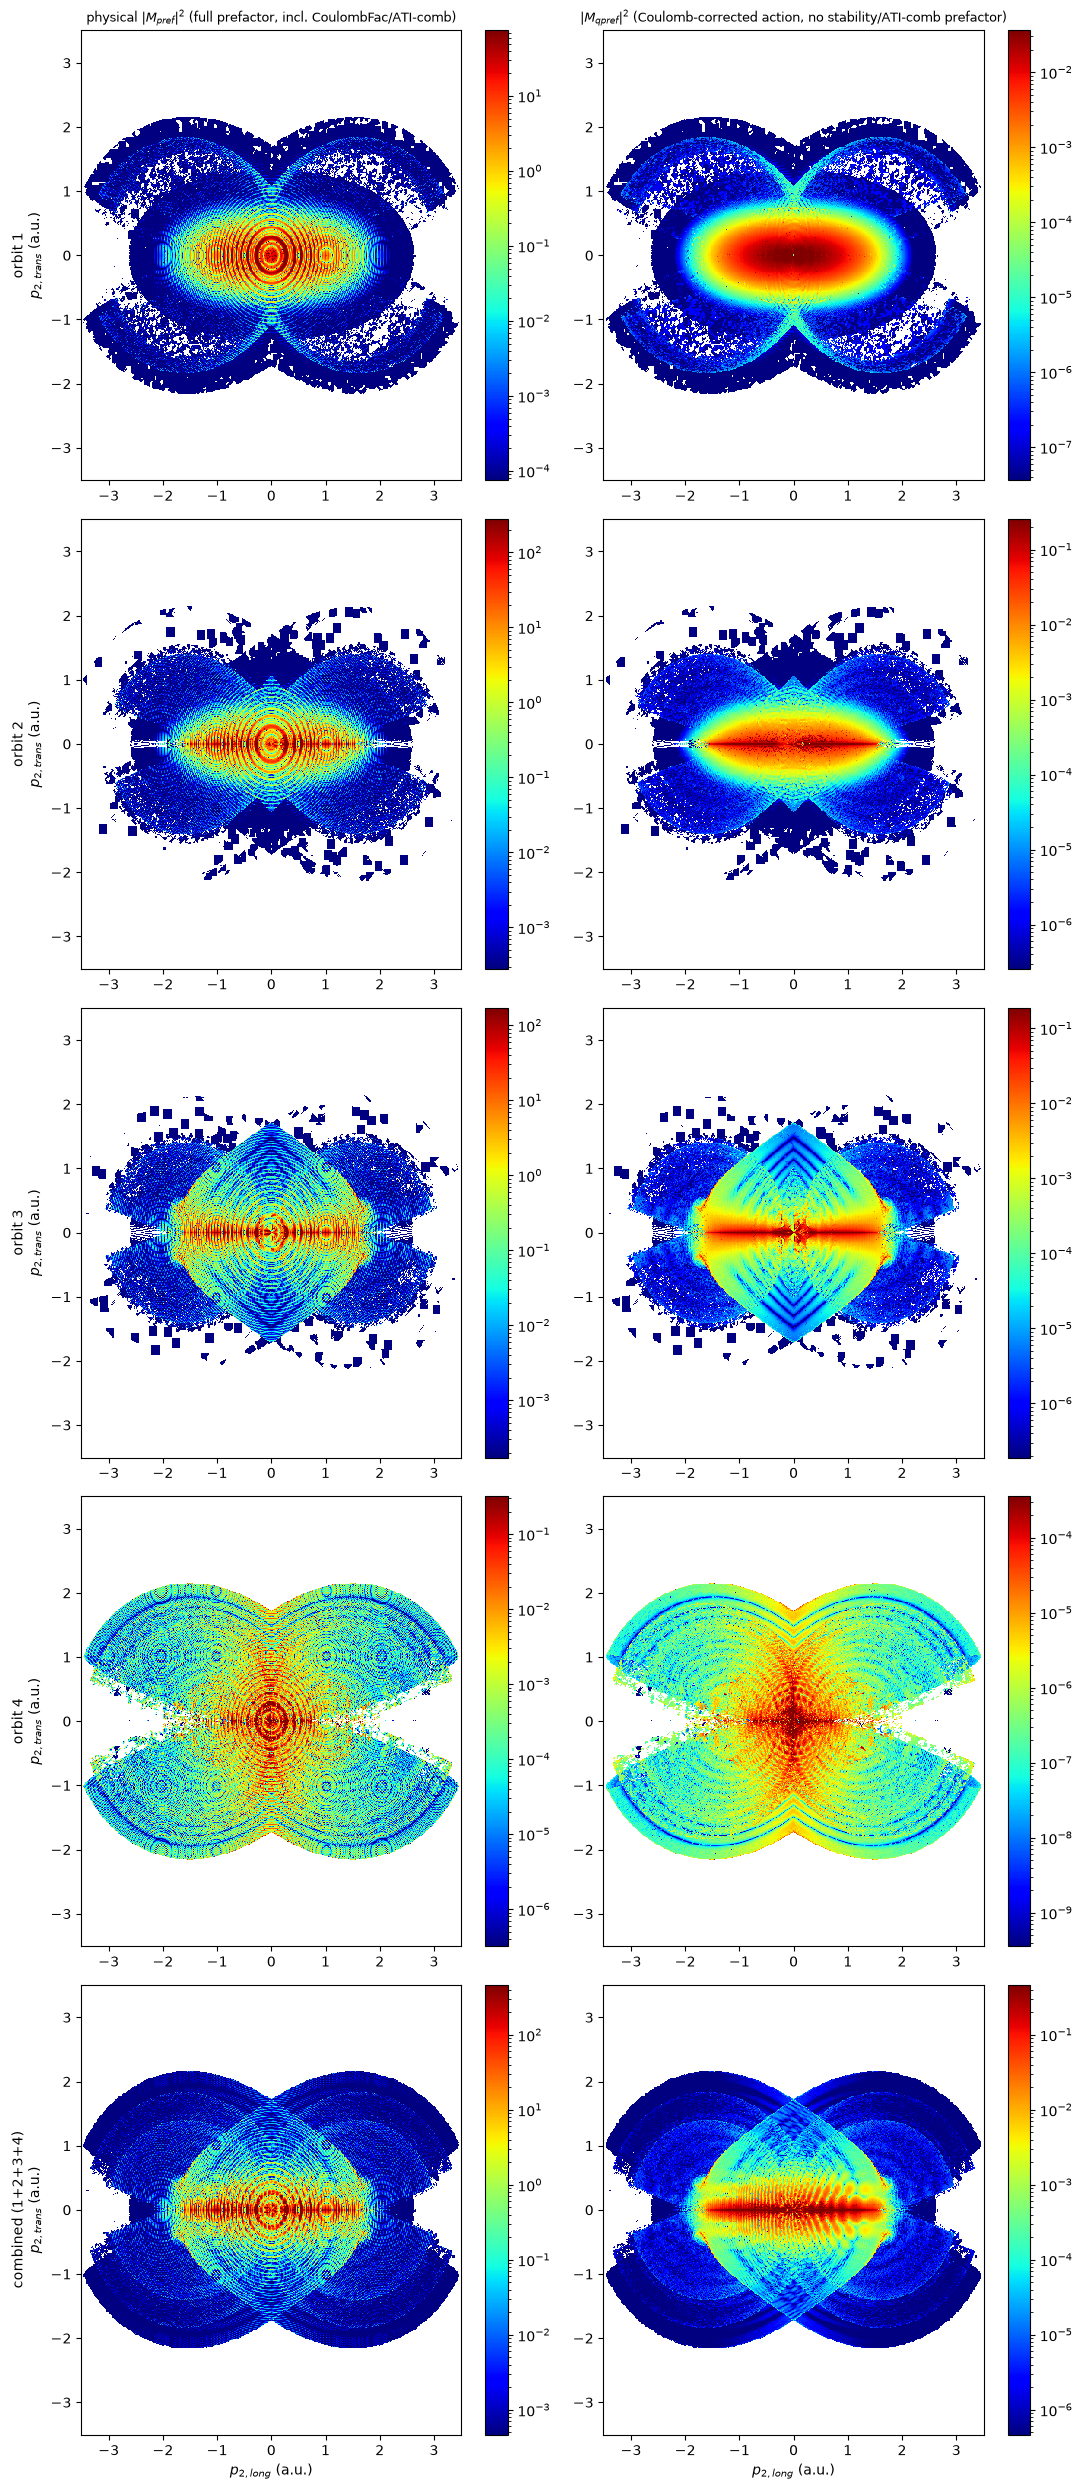

In [4]:
def load_amplitude_fq(orbit_num=None):
    # orbit_num=None -> combined Amplitude_Grid (all included orbits, coherent);
    # else the native per-orbit Amplitude_Grid_orbit<N> breakdown.
    prefix = f"Amplitude_Grid_orbit{orbit_num}_" if orbit_num is not None else "Amplitude_Grid_"
    path = f"{CQSFA_dir}/Data/{prefix}Frankenstein_He_electron2_{RUN_TAG}_{AMP_GRID_TAG}.dat"
    amp_data = np.loadtxt(path)
    pz = amp_data[:, 0].reshape(Nz, Ny)[:, 0]
    py = amp_data[:, 1].reshape(Nz, Ny)[0, :]
    quantities = {
        "full": np.abs(amp_data[:, 8]).reshape(Nz, Ny),
        "qpref": np.abs(amp_data[:, 11]).reshape(Nz, Ny),
    }
    return pz, py, quantities


TITLES = {
    "full": "physical $|M_{pref}|^2$ (full prefactor, incl. CoulombFac/ATI-comb)",
    "qpref": "$|M_{qpref}|^2$ (Coulomb-corrected action, no stability/ATI-comb prefactor)",
}

ROWS = [1, 2, 3, 4, None]
ROW_LABELS = {1: "orbit 1", 2: "orbit 2", 3: "orbit 3", 4: "orbit 4", None: "combined (1+2+3+4)"}

fig, axes = plt.subplots(len(ROWS), 2, figsize=(11, 5 * len(ROWS)))
for row, orbit_num in enumerate(ROWS):
    pz, py, quantities = load_amplitude_fq(orbit_num)
    label = ROW_LABELS[orbit_num]
    for col, (key, d) in enumerate(quantities.items()):
        ax = axes[row, col]
        mask = d > 0
        vmax = np.percentile(d[mask], 99.5) if mask.any() else 1.0
        pcm = ax.pcolormesh(pz, py, d.T, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
        if row == len(ROWS) - 1:
            ax.set_xlabel(r"$p_{2,long}$ (a.u.)")
        ax.set_ylabel(f"{label}\n" + r"$p_{2,trans}$ (a.u.)" if col == 0 else "")
        if row == 0:
            ax.set_title(TITLES[key], fontsize=9)
        fig.colorbar(pcm, ax=ax)
plt.tight_layout()
plt.show()


## 2. Initial conditions: combined and separated by orbit type

`Binned_Initial_Condition_Grid` raw solved trajectories. Classification follows
`initCondsGrid::pointType()`: orb1 = (z0*pf_par+, pf_perp*p0_perp+), orb2 = (-,+), orb3 = (-,-),
orb4 = (+,-).

Loading Binned_Initial_Condition_Grid....
Loaded 1212635 points, orbit counts:
orbit
1    240138
2    286492
3    296308
4    389697
Name: count, dtype: int64


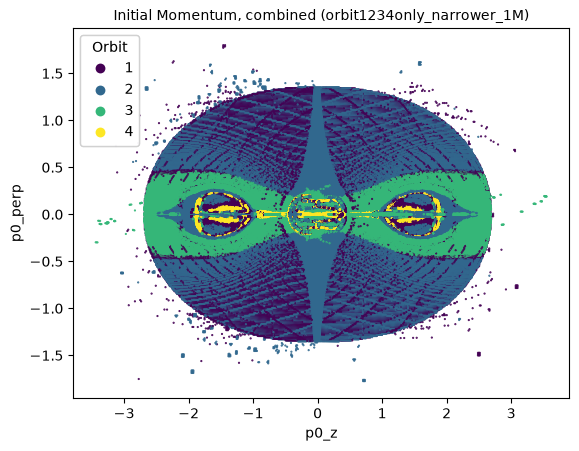

In [5]:
COLUMNS = [
    "p0_z", "p0_perp", "p0_x",
    "t0_re", "t0_im", "z0",
    "pf_z", "pf_perp", "pf_x",
    "orbit",
    "rf_z", "rf_perp", "rf_x",
    "Vmax", "Rmin",
]

print("Loading Binned_Initial_Condition_Grid....")
cqsfa_data = np.loadtxt(f"{CQSFA_dir}/Data/Binned_Initial_Condition_Grid_Frankenstein_He_electron2_{RUN_TAG}_{NINITCOND_TAG}.dat")
df = pd.DataFrame(cqsfa_data, columns=COLUMNS)
df["orbit"] = df["orbit"].astype(int)
print(f"Loaded {len(df)} points, orbit counts:")
print(df["orbit"].value_counts().sort_index())

fig, ax = plt.subplots()
scatter = ax.scatter(df["p0_z"], df["p0_perp"], c=df["orbit"], s=0.3, cmap="viridis")
ax.set_title(f"Initial Momentum, combined ({RUN_TAG})", fontsize=10)
ax.set_xlabel("p0_z", fontsize=10)
ax.set_ylabel("p0_perp", fontsize=10)
legend1 = ax.legend(*scatter.legend_elements(), loc="upper left", title="Orbit")
ax.add_artist(legend1)
plt.show()


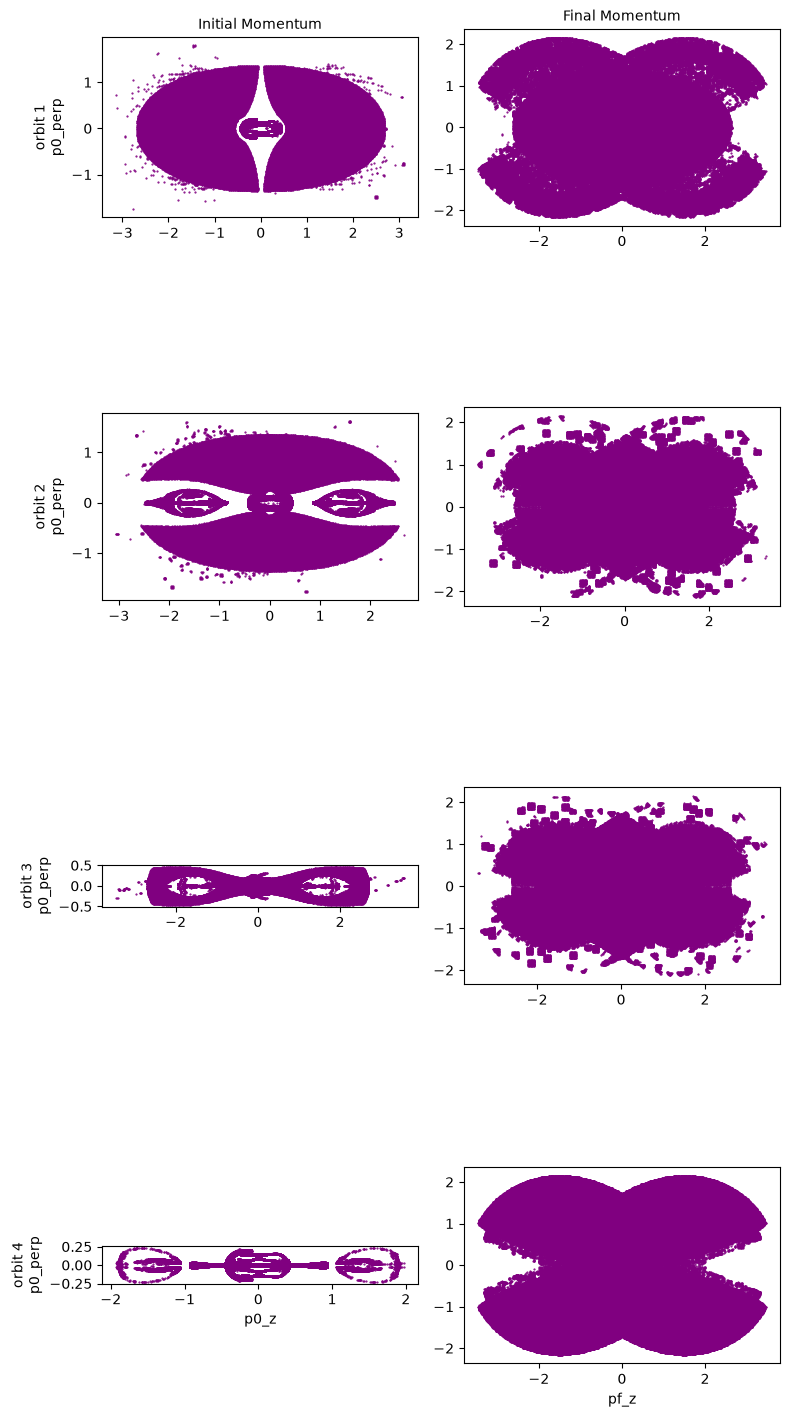

In [6]:
orbits = [1, 2, 3, 4]
fig, axes = plt.subplots(len(orbits), 2, figsize=(8, 4 * len(orbits)))

for row, orbit in enumerate(orbits):
    df_orbit = df[df["orbit"] == orbit]
    ax1, ax2 = axes[row]

    ax1.scatter(df_orbit["p0_z"], df_orbit["p0_perp"], s=0.3, color="purple")
    ax1.set(adjustable="box", aspect="equal")
    ax1.set_ylabel(f"orbit {orbit}\np0_perp", fontsize=10)
    if row == 0:
        ax1.set_title("Initial Momentum", fontsize=10)

    ax2.scatter(df_orbit["pf_z"], df_orbit["pf_perp"], s=0.3, color="purple")
    ax2.set(adjustable="box", aspect="equal")
    if row == 0:
        ax2.set_title("Final Momentum", fontsize=10)

axes[-1][0].set_xlabel("p0_z", fontsize=10)
axes[-1][1].set_xlabel("pf_z", fontsize=10)
plt.tight_layout()
plt.show()


## 3. Frankenstein joint (p1,p2) distributions vs. standard SFA RESI

Built via the validated **separable, no-interpolation** method: the exact algebra of
`getA_from_e2factor`/`getMij_C`/`getMij_Q` shows `M(p1,p2)` factors EXACTLY as
`exp(i*S2(p2)) * e2_factor(p2) * M1_uniform(p1)` - electron 2's CQSFA-dependent piece is always a
pure per-point complex scalar. So the joint marginal is an exact outer product `A1(p1) x A2(p2)`,
and `A2(p2)` can be read directly off CQSFA_fwd's own native (non-interpolated) `Amplitude_Grid`
complex amplitude columns - avoiding the noise that griddata-interpolating the raw solved action
introduced (see `Frankenstein_orbit1234_narrower_1M.ipynb` for the full derivation/diagnosis).
All panels use consistent `p/sqrt(Up)` units, with cyan dashed lines marking the +/-2Up bound.

In [11]:
_COMPLEX_COLS = {"full": (6, 7), "qpref": (9, 10)}


def load_amplitude_complex(orbit_num=None):
    # Same file/shape convention as load_amplitude_fq(), but keeps the COMPLEX amplitude (not
    # |M|^2) so per-orbit-type results can be coherently SUMMED before squaring, matching how
    # Amplitude::calculatePoint combines orbit types natively in C++.
    prefix = f"Amplitude_Grid_orbit{orbit_num}_" if orbit_num is not None else "Amplitude_Grid_"
    path = f"{CQSFA_dir}/Data/{prefix}Frankenstein_He_electron2_{RUN_TAG}_{AMP_GRID_TAG}.dat"
    amp_data = np.loadtxt(path)
    pz = amp_data[:, 0].reshape(Nz, Ny)[:, 0]
    py = amp_data[:, 1].reshape(Nz, Ny)[0, :]
    M_by_mode = {
        mode: (amp_data[:, re_col] + 1j * amp_data[:, im_col]).reshape(Nz, Ny)
        for mode, (re_col, im_col) in _COMPLEX_COLS.items()
    }
    return pz, py, M_by_mode


PREFACTOR_MODE = "qpref"  # "full" | "qpref"

# Electron 1's own uniform-approximation marginal is independent of electron 2/orbit entirely -
# setting s2=0, e2_factor=1 isolates M1_uniform(i,ii) exactly (any single j,jj slice is
# representative, since the now-constant electron-2 factor no longer varies with j,jj at all).
_valid_e1 = np.ones((n, hsize), dtype=bool)
M1_only = compute_M_native(params, e1_times, np.zeros((n, hsize)), np.ones((n, hsize), dtype=complex), _valid_e1)
A1 = (np.abs(M1_only[:, 0, :, 0]) ** 2 * np.abs(tax_half)).sum(axis=1)
del M1_only
print(f"A1 (electron 1 own marginal, orbit-independent) computed: shape={A1.shape}, max={A1.max():.3e}")


A1 (electron 1 own marginal, orbit-independent) computed: shape=(141,), max=1.463e-07


In [8]:
# Per-orbit COMPLEX native amplitude, coherently summed into "12"/"34"/"1234" combos - built
# ENTIRELY from CQSFA_fwd's own directly-solved grid, no griddata anywhere.
M2_by_combo = {}
group_M2 = {}
pz_native = py_native = None

for orbit_num in (1, 2, 3, 4):
    pz_native, py_native, M_by_mode = load_amplitude_complex(orbit_num)
    M2 = M_by_mode[PREFACTOR_MODE]
    M2_by_combo[str(orbit_num)] = M2
    pair_key = "12" if orbit_num in (1, 2) else "34"
    group_M2[pair_key] = M2 if pair_key not in group_M2 else group_M2[pair_key] + M2

M2_by_combo["12"] = group_M2["12"]
M2_by_combo["34"] = group_M2["34"]
M2_by_combo["1234"] = group_M2["12"] + group_M2["34"]
del group_M2

A2_by_combo = {key: np.trapezoid(np.abs(M2) ** 2, py_native, axis=1) for key, M2 in M2_by_combo.items()}
prob_native_by_combo = {key: np.outer(A1, A2) for key, A2 in A2_by_combo.items()}

# Standard SFA RESI reference (Coulomb-free, OrbitFinder long branch) for comparison.
valid_all = np.ones((n, hsize), dtype=bool)
t_start = time.time()
M_sfa_long = compute_M(params, e1_times, T3L[:, :hsize], valid_all)
prob_sfa_resi = (np.abs(M_sfa_long) ** 2 * p1trans_w * p2trans_w).sum(axis=(2, 3))
print(f"SFA RESI elapsed: {time.time() - t_start:.1f}s")


SFA RESI elapsed: 125.5s


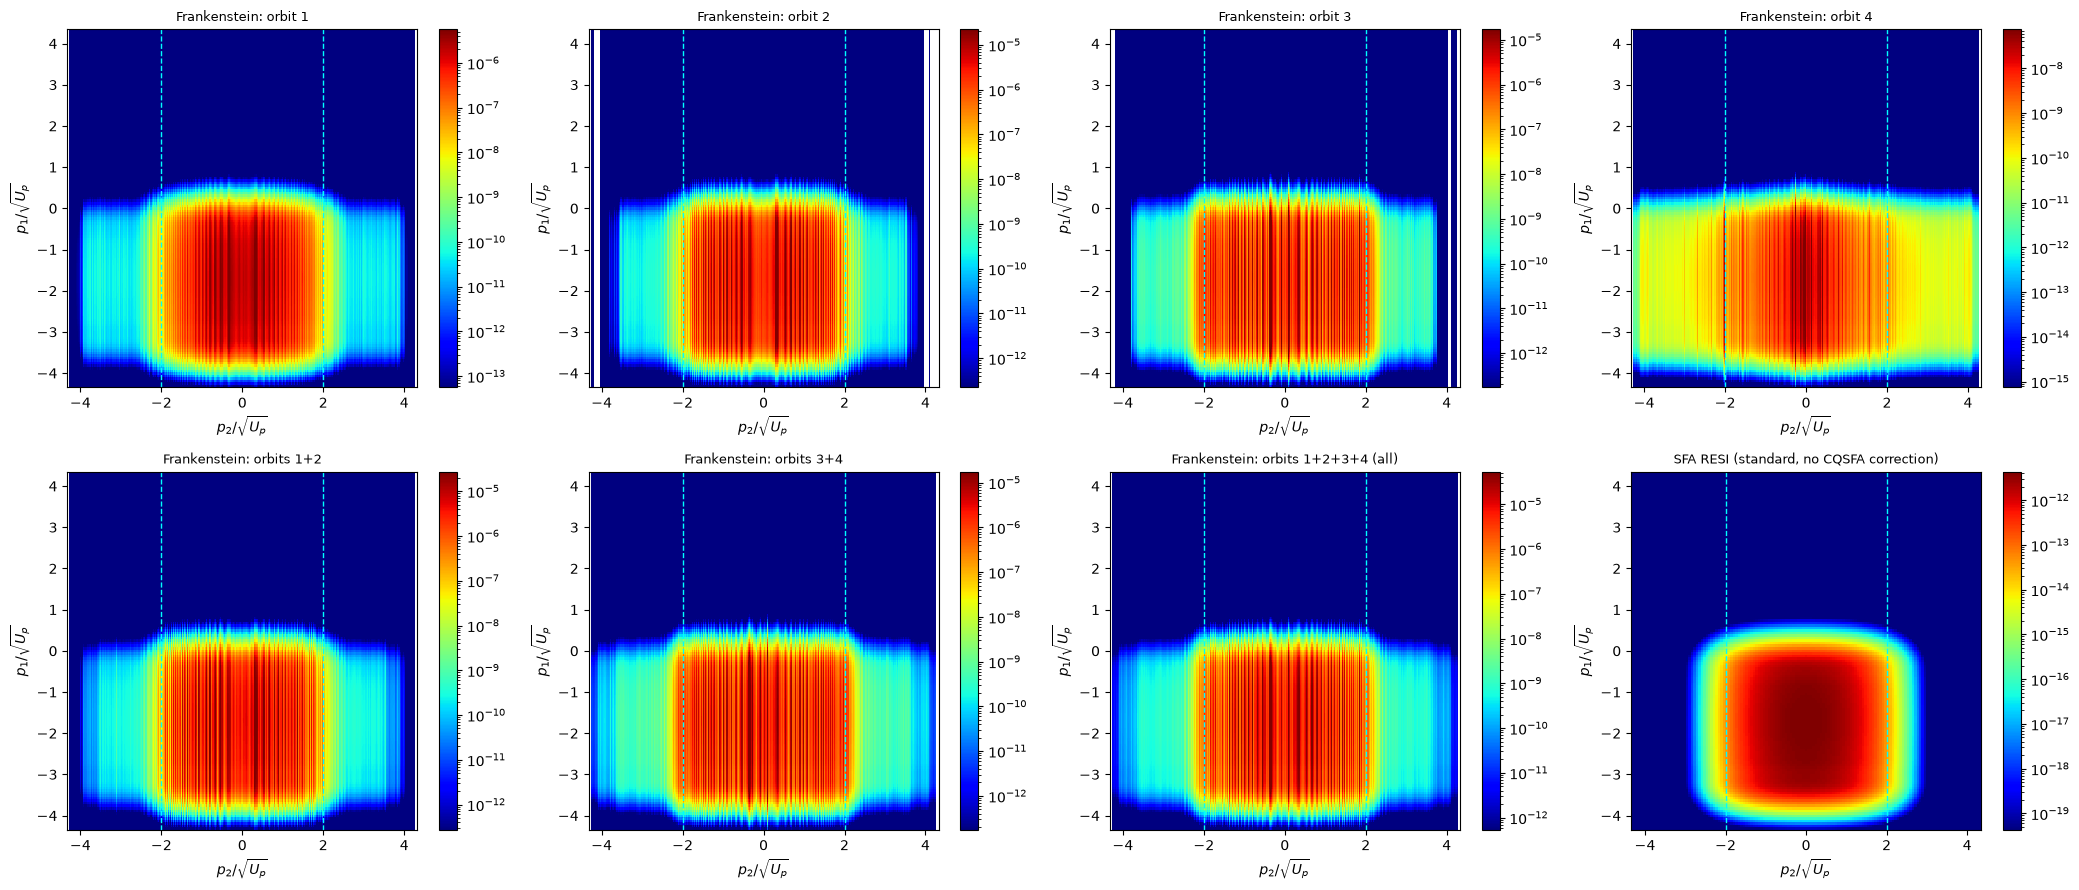

In [9]:
combo_labels = {
    "1": "orbit 1", "2": "orbit 2", "3": "orbit 3", "4": "orbit 4",
    "12": "orbits 1+2", "34": "orbits 3+4", "1234": "orbits 1+2+3+4 (all)",
}

fig, axes = plt.subplots(2, 4, figsize=(21, 9))
for ax, key in zip(axes.flat, list(combo_labels) + ["sfa"]):
    if key == "sfa":
        d, x_axis, title = np.abs(prob_sfa_resi), pax, "SFA RESI (standard, no CQSFA correction)"
    else:
        d, x_axis, title = prob_native_by_combo[key], pz_native / np.sqrt(Up), f"Frankenstein: {combo_labels[key]}"
    mask = d > 0
    vmax = np.percentile(d[mask], 99.5) if mask.any() else 1.0
    pcm = ax.pcolormesh(x_axis, pax, d, norm=LogNorm(vmin=vmax * 1e-8, vmax=vmax), shading="auto", cmap="jet")
    ax.axvline(2, color="cyan", ls="--", lw=1); ax.axvline(-2, color="cyan", ls="--", lw=1)
    ax.set_xlabel(r"$p_{2}/\sqrt{U_p}$"); ax.set_ylabel(r"$p_{1}/\sqrt{U_p}$")
    ax.set_title(title, fontsize=9)
    fig.colorbar(pcm, ax=ax)
plt.tight_layout()
plt.show()


## 4. Electron momentum distributions: SFA (both electrons) vs. CQSFA (electron 2)

(a)/(b): electron 1 and electron 2's own (p_parallel, p_perpendicular) marginals under the pure
Coulomb-free SFA RESI model (`M_sfa_long`, from Section 3), matching Shaaran, Nygren & Figueira de
Morisson Faria, *PRA* **85**, 023423 (2012), Eq. (17)/(18). (c): the Frankenstein JOINT (p1,p2)
reconstruction for orbits 1+2+3+4 (Section 3, `qPref`/stability-only mode). (d): electron 2's own
native CQSFA marginal (all 4 orbits, coherent), stability-only (`qPref`).

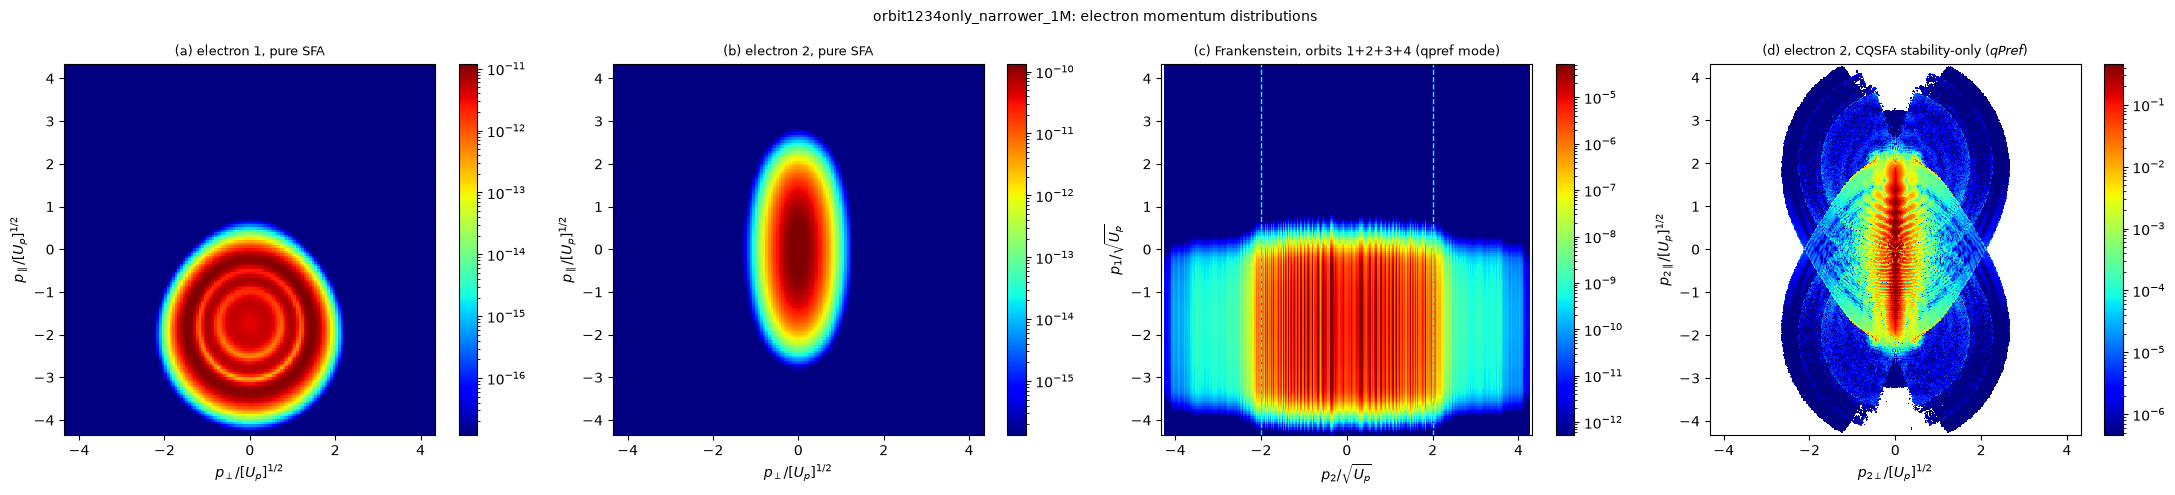

In [12]:
def mirror_perp(axis, data, trans_axis=-1):
    # `axis` (tax_half) is the NON-POSITIVE half (ascending, last entry ~0) - mirror it to the
    # positive side for a full symmetric (-max..max) axis/data, no duplicate zero.
    trimmed = np.delete(data, -1, axis=trans_axis)
    full_data = np.concatenate([data, np.flip(trimmed, axis=trans_axis)], axis=trans_axis)
    full_axis = np.concatenate([axis, -axis[:-1][::-1]])
    return full_axis, full_data


# (a)/(b): marginalize M_sfa_long over the OTHER electron's (long,trans) pair entirely. tax_half
# (hence p1trans_w/p2trans_w) is <=0 valued - use np.abs() for a proper polar |p_perp| Jacobian
# when only ONE of the two weights appears (unlike prob_of()'s product of two negative factors).
prob_e1_par_perp_sfa = (np.abs(M_sfa_long) ** 2 * np.abs(p2trans_w)).sum(axis=(1, 3))
prob_e2_par_perp_sfa = (np.abs(M_sfa_long) ** 2 * np.abs(p1trans_w)).sum(axis=(0, 2))

tax_full, e1_full = mirror_perp(tax_half, np.abs(prob_e1_par_perp_sfa))
_, e2_full = mirror_perp(tax_half, np.abs(prob_e2_par_perp_sfa))

# (c)/(d): CQSFA's own native combined (all orbits) marginal - already the correct quantity,
# no interpolation/reconstruction needed at all.
pz_amp, py_amp, amp_quantities = load_amplitude_fq(None)
p2_par_su = pz_amp / np.sqrt(Up)
p2_perp_su = py_amp / np.sqrt(Up)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, d, title in [
    (axes[0], e1_full, "(a) electron 1, pure SFA"),
    (axes[1], e2_full, "(b) electron 2, pure SFA"),
]:
    mask = d > 0
    vmax = np.percentile(d[mask], 99.5) if mask.any() else 1.0
    pcm = ax.pcolormesh(tax_full, pax, d, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
    ax.set_xlabel(r"$p_{\perp}/[U_p]^{1/2}$"); ax.set_ylabel(r"$p_{\parallel}/[U_p]^{1/2}$")
    ax.set_title(title, fontsize=9)
    fig.colorbar(pcm, ax=ax)

# (c): Frankenstein orbits 1+2+3+4 JOINT (p1,p2) reconstruction (Section 3, same PREFACTOR_MODE) -
# for direct comparison against (d)'s single-electron native marginal under the SAME weighting.
d_c = prob_native_by_combo["1234"]
mask = d_c > 0
vmax = np.percentile(d_c[mask], 99.5) if mask.any() else 1.0
pcm = axes[2].pcolormesh(pz_native / np.sqrt(Up), pax, d_c, norm=LogNorm(vmin=vmax * 1e-8, vmax=vmax), shading="auto", cmap="jet")
axes[2].axvline(2, color="cyan", ls="--", lw=1); axes[2].axvline(-2, color="cyan", ls="--", lw=1)
axes[2].set_xlabel(r"$p_{2}/\sqrt{U_p}$"); axes[2].set_ylabel(r"$p_{1}/\sqrt{U_p}$")
axes[2].set_title(f"(c) Frankenstein, orbits 1+2+3+4 ({PREFACTOR_MODE} mode)", fontsize=9)
fig.colorbar(pcm, ax=axes[2])

d_d = amp_quantities["qpref"]
mask = d_d > 0
vmax = np.percentile(d_d[mask], 99.5) if mask.any() else 1.0
pcm = axes[3].pcolormesh(p2_perp_su, p2_par_su, d_d, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
axes[3].set_xlabel(r"$p_{2\perp}/[U_p]^{1/2}$"); axes[3].set_ylabel(r"$p_{2\parallel}/[U_p]^{1/2}$")
axes[3].set_title("(d) electron 2, CQSFA stability-only ($qPref$)", fontsize=9)
fig.colorbar(pcm, ax=axes[3])

fig.suptitle(f"{RUN_TAG}: electron momentum distributions", fontsize=10)
plt.tight_layout()
plt.show()